In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('china_ai_growth_dataset_2010_2026.csv')

In [8]:
#print the dataset
df.convert_dtypes(convert_string=True)

,Year,Country,AI Publication Share (%),AI Total Publications,AI Investment Billion USD,Government AI Spending In Billions(USD),Private AI Investment In Billions(USD),AI Companies Count,AI Startups Count,AI Patents Share (%),R&D Expenditure (% of GDP),AI Growth Rate (%)
0,2010,China,12,20000,3.0,1.2,1.8,800,300,20,1.71,0
1,2011,China,13,23000,3.5,1.4,2.1,900,350,22,1.78,15
2,2012,China,14,26000,4.0,1.6,2.4,1000,400,25,1.91,14
3,2013,China,16,30000,4.8,2.0,2.8,1200,500,28,2.0,18
4,2014,China,18,35000,5.5,2.3,3.2,1500,650,32,2.02,16
5,2015,China,20,42000,6.5,2.8,3.7,2000,900,40,2.06,20
6,2016,China,23,50000,7.8,3.3,4.5,2500,1200,48,2.1,22
7,2017,China,26,60000,9.0,3.8,5.2,3000,1500,55,2.13,18
8,2018,China,28,70000,10.5,4.5,6.0,3200,1800,60,2.19,17
9,2019,China,29,80000,11.0,4.7,6.3,3400,2000,62,2.24,10


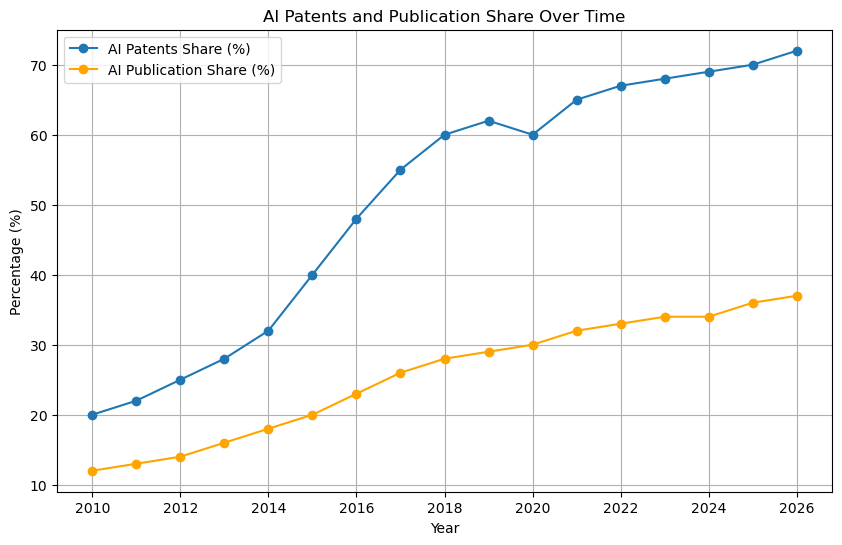

In [7]:
#Question: What is the historical "decoupling" point between AI Research (Publications) and AI Commercialization (Patents)?
#create a linegraph to show the growth of AI patents and publications over time
fig, ax = plt.subplots(figsize=(10, 6))


df.plot(x='Year', y=['AI Patents Share (%)', 'AI Publication Share (%)'], 
        kind='line', marker='o', ax=ax, color=['#1f77b4', 'orange'])


ax.set_title('AI Patents and Publication Share Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)') 
ax.grid(True)


plt.show()


Coefficient of Determination (R²): 99.6327%


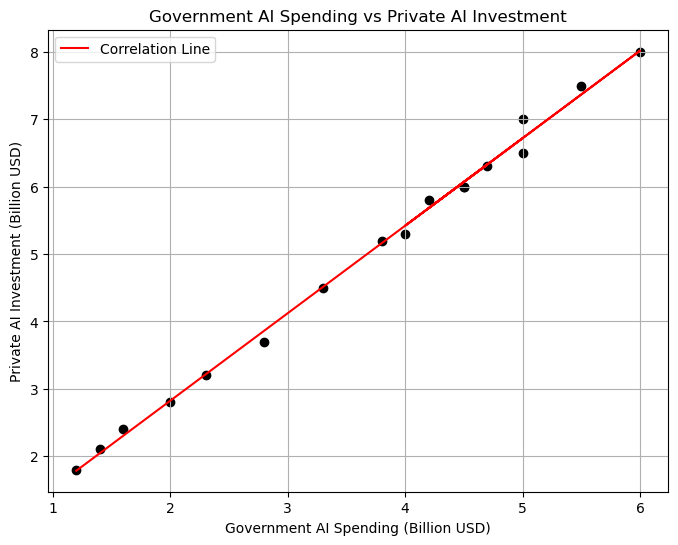

In [6]:
#Question 2: Does Government spending act as a "Catalyst" or a "Safety Net" for Private Investment?
#crete a scatter plot to show the relationship between government spending and private investment in AI, and add a line of best fit to show the correlation
import numpy as np 

plt.figure(figsize=(8, 6))
plt.scatter(df['Government AI Spending In Billions(USD)'], df['Private AI Investment In Billions(USD)'], color='black')

x = df['Government AI Spending In Billions(USD)']
y = df['Private AI Investment In Billions(USD)']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label='Correlation Line')

correlation_matrix = np.corrcoef(df['Government AI Spending In Billions(USD)'], df['Private AI Investment In Billions(USD)'])
r_value = correlation_matrix[0, 1]
r_squared = (r_value ** 2) * 100
print(f'Coefficient of Determination (R²): {r_squared:.4f}%')

plt.title('Government AI Spending vs Private AI Investment')
plt.xlabel('Government AI Spending (Billion USD)')
plt.ylabel('Private AI Investment (Billion USD)')
plt.legend()
plt.grid(True)
plt.show()

R&D Expenditure (% of GDP): 17.1679
Private AI Investment In Billions(USD): 4.1048
AI Startups Count: -0.0127


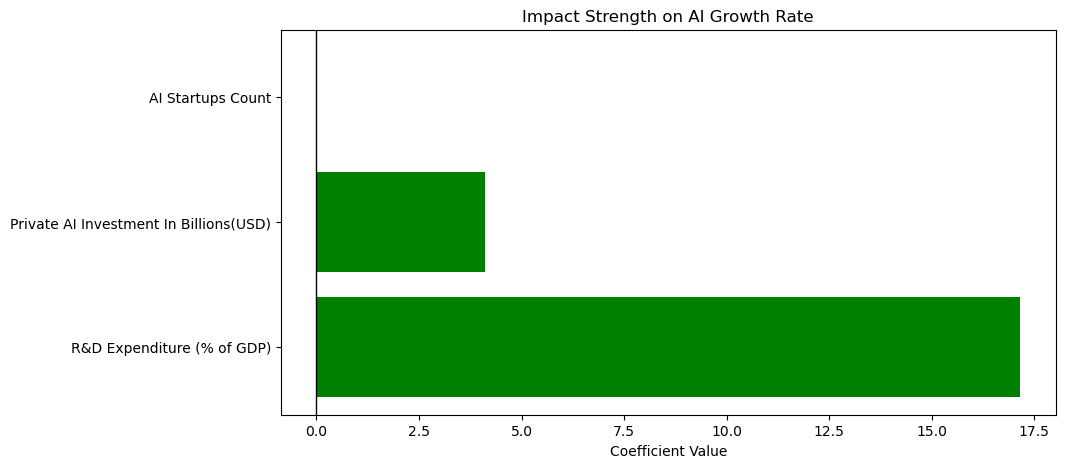

In [5]:
#Question 3: Which factor is the strongest predictor of the AI_Growth_Rate (%)?
from sklearn.linear_model import LinearRegression
#linear regression model to predict AI Growth Rate based on R&D Expenditure, AI Investment, and AI Startups Count
X = df[['R&D Expenditure (% of GDP)', 'Private AI Investment In Billions(USD)', 'AI Startups Count']]
Y = df['AI Growth Rate (%)']
model = LinearRegression()
model.fit(X, Y)
coefficients = model.coef_
feature_names = X.columns
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

names = feature_names
values = coefficients

plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in values]
plt.barh(names, values, color=colors)
plt.title('Impact Strength on AI Growth Rate')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', lw=1) 
plt.show()

Year: 2027, Projected AI Companies Count: 5620, Projected AI Total Publications: 173868
Year: 2028, Projected AI Companies Count: 5899, Projected AI Total Publications: 188216
Year: 2029, Projected AI Companies Count: 6177, Projected AI Total Publications: 203127


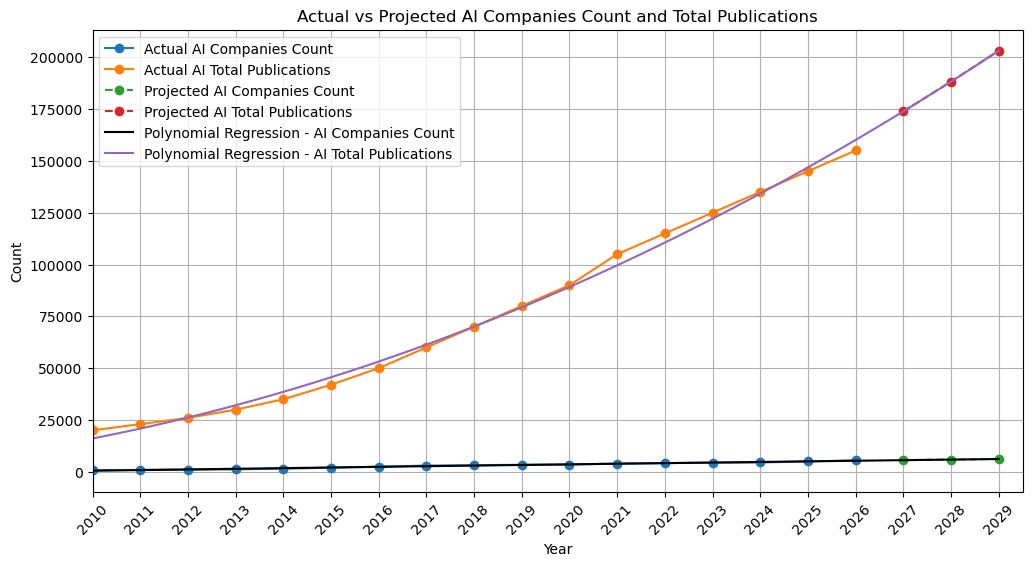

In [4]:
#Question 4: Based on current trajectories, what is the projected AI_Companies_Count and AI Total Publications for the next 3 years?
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = df['Year'].values.reshape(-1, 1)

y_companies = df['AI Companies Count'].values
y_publications = df['AI Total Publications'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_companies = LinearRegression()
model_companies.fit(X_poly, y_companies)

model_publications = LinearRegression()
model_publications.fit(X_poly, y_publications)

future_years = np.array([2027, 2028, 2029]).reshape(-1, 1)
future_years_poly = poly.transform(future_years)

predicted_companies = model_companies.predict(future_years_poly)
predicted_publications = model_publications.predict(future_years_poly)

for year, companies, publications in zip(future_years.flatten(), predicted_companies, predicted_publications):
    print(f'Year: {year}, Projected AI Companies Count: {companies:.0f}, Projected AI Total Publications: {publications:.0f}')
#show the line and polynomial regression lines for both AI Companies Count and AI Total Publications, 
#and also show the actual data points for both AI Companies Count and AI Total Publications, 
# with the x-axis showing the years from 2010 to 2029, and the y-axis showing the count for both AI Companies and AI Total Publications. 
# Also, make sure to include a legend to differentiate between actual and projected values, and add grid lines for better readability.

X_smooth = np.linspace(2010, 2029, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)
curve_companies = model_companies.predict(X_smooth_poly)
curve_publications = model_publications.predict(X_smooth_poly)

plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['AI Companies Count'], marker='o', label='Actual AI Companies Count')
plt.plot(df['Year'], df['AI Total Publications'], marker='o', label='Actual AI Total Publications')
plt.plot(future_years, predicted_companies, marker='o', linestyle='--', label='Projected AI Companies Count')
plt.plot(future_years, predicted_publications, marker='o', linestyle='--', label='Projected AI Total Publications')
plt.plot(X_smooth, curve_companies, color='black',linestyle='-', label='Polynomial Regression - AI Companies Count')
plt.plot(X_smooth, curve_publications, linestyle='-', label='Polynomial Regression - AI Total Publications')

all_years = np.arange(df['Year'].min(), 2030, 1) 
plt.xticks(all_years, rotation=45)
plt.xlim(df['Year'].min(), 2029.5)

plt.title('Actual vs Projected AI Companies Count and Total Publications')

plt.xlabel('Year')
plt.ylabel('Count')

plt.legend()
plt.grid(True)

plt.show()


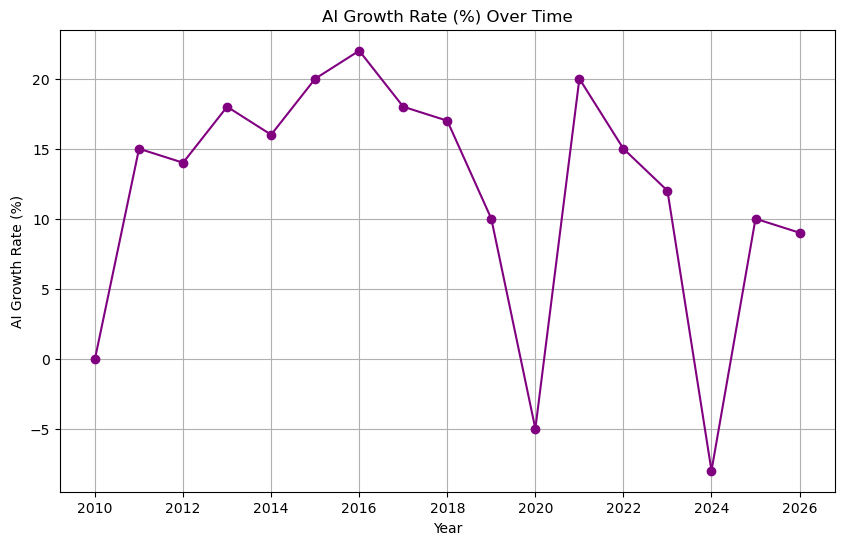

In [ ]:
#Question 5: When did China experience a significant acceleration on AI Growth?
#Make a line graph to show the AI Growth Rate (%) over time, and identify the year(s) where there is a noticeable increase or decrease in the growth rate.
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['AI Growth Rate (%)'], marker='o', color='purple')
plt.title('AI Growth Rate (%) Over Time')
plt.xlabel('Year')
plt.ylabel('AI Growth Rate (%)')
plt.grid(True)
plt.show()

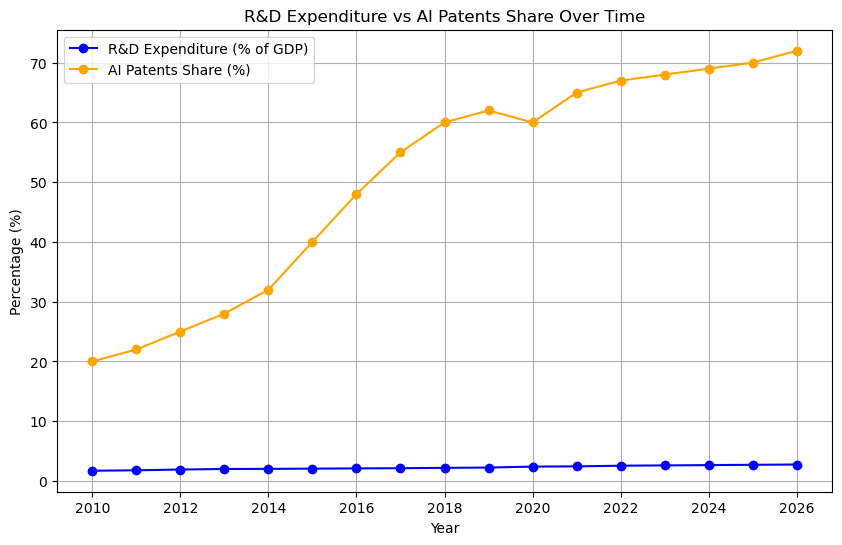

In [11]:
#Question 6: Is there a lag between R&D Expenditure and AI Patents Share (%)?
#identify if the increase in R&D Expenditure budget affects the next years AI Patents Share (%)
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['R&D Expenditure (% of GDP)'], marker='o', label='R&D Expenditure (% of GDP)', color='blue')
plt.plot(df['Year'], df['AI Patents Share (%)'], marker='o', label='AI Patents Share (%)', color='orange')
plt.title('R&D Expenditure vs AI Patents Share Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)
plt.show()


Year: 2027, Projected AI Growth Rate (%): 7.73%
Year: 2028, Projected AI Growth Rate (%): 7.26%
Year: 2029, Projected AI Growth Rate (%): 6.79%
Year: 2030, Projected AI Growth Rate (%): 6.32%
Year: 2031, Projected AI Growth Rate (%): 5.86%
Year: 2032, Projected AI Growth Rate (%): 5.39%
Year: 2033, Projected AI Growth Rate (%): 4.92%
Year: 2034, Projected AI Growth Rate (%): 4.45%
Year: 2035, Projected AI Growth Rate (%): 3.98%
Year: 2036, Projected AI Growth Rate (%): 3.51%


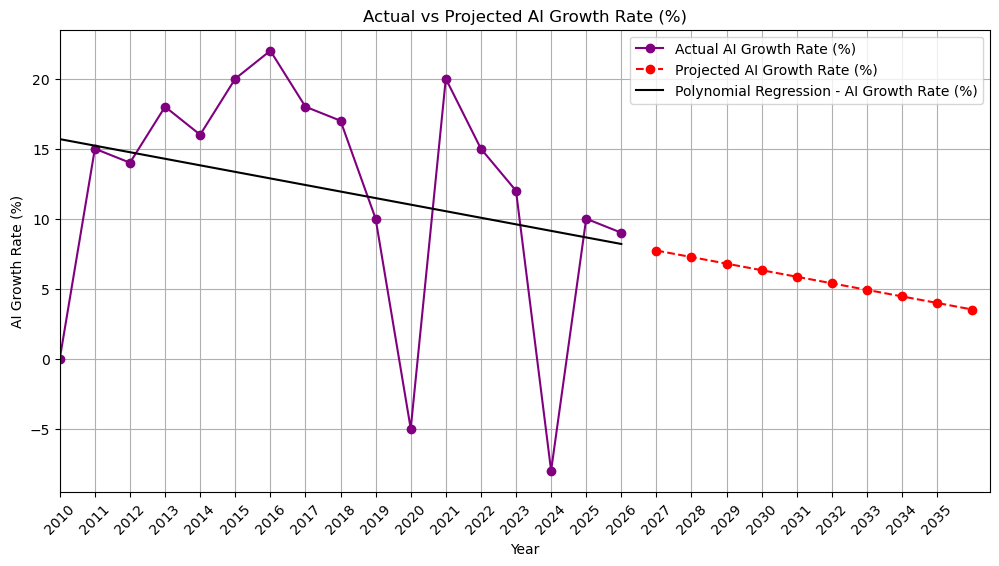

In [16]:
#Question 7: Is China's groweth sustainable in the long term, or is it likely to face a slowdown or plateau in the future?
#Create a graph predicting the next 10 years of AI Growth Rate (%) based on the historical data, and analyze the trend to determine
#  if there is a potential for slowdown or plateau in the future and place a 5th-degree polynomial regression line for the AI Growth Rate (%) 
# over time, and also show the actual data points for AI Growth Rate (%)
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = df['Year'].values.reshape(-1, 1)
y_growth_rate = df['AI Growth Rate (%)'].values
poly = PolynomialFeatures(degree=1)
X_poly = poly.fit_transform(X)
model_growth_rate = LinearRegression()
model_growth_rate.fit(X_poly, y_growth_rate)
future_years = np.array([2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]).reshape(-1, 1)
future_years_poly = poly.transform(future_years)
predicted_growth_rate = model_growth_rate.predict(future_years_poly)
for year, growth_rate in zip(future_years.flatten(), predicted_growth_rate):
    print(f'Year: {year}, Projected AI Growth Rate (%): {growth_rate:.2f}%')
X_smooth = np.linspace(2010, 2026, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)
curve_growth_rate = model_growth_rate.predict(X_smooth_poly)
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['AI Growth Rate (%)'], marker='o', label='Actual AI Growth Rate (%)', color='purple')
plt.plot(future_years, predicted_growth_rate, marker='o', linestyle='--', label='Projected AI Growth Rate (%)', color='red')
plt.plot(X_smooth, curve_growth_rate, color='black', linestyle='-', label='Polynomial Regression - AI Growth Rate (%)')
all_years = np.arange(df['Year'].min(), 2036, 1) 
plt.xticks(all_years, rotation=45)
plt.xlim(df['Year'].min(), 2036.5)
plt.title('Actual vs Projected AI Growth Rate (%)')
plt.xlabel('Year')
plt.ylabel('AI Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.show()



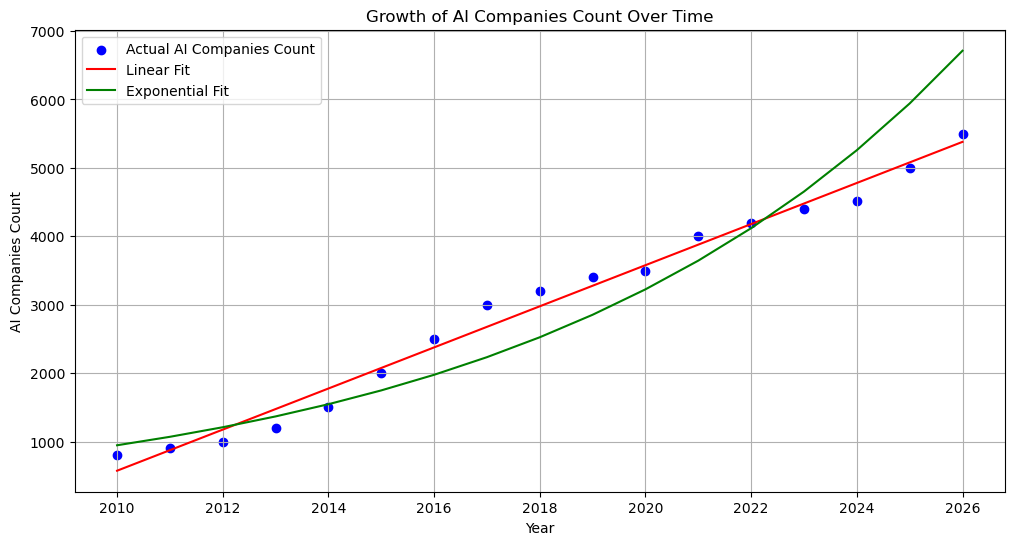

In [17]:
#Question 8: Is Chinas growth in AI Linear or Exponential?
#Create a graph to show the growth of AI Companies Count over time, and fit both a linear and an exponential regression line 
#to the data, and analyze the fit of both models to determine if China's growth in AI is more linear or exponential.
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
X = df['Year'].values.reshape(-1, 1)
y_companies = df['AI Companies Count'].values
model_linear = LinearRegression()
model_linear.fit(X, y_companies)
y_pred_linear = model_linear.predict(X)
model_exponential = make_pipeline(FunctionTransformer(np.log, validate=True), LinearRegression())
model_exponential.fit(X, np.log(y_companies))
y_pred_exponential = np.exp(model_exponential.predict(X))
plt.figure(figsize=(12, 6))
plt.scatter(df['Year'], df['AI Companies Count'], color='blue', label='Actual AI Companies Count')
plt.plot(df['Year'], y_pred_linear, color='red', label='Linear Fit')
plt.plot(df['Year'], y_pred_exponential, color='green', label='Exponential Fit')
plt.title('Growth of AI Companies Count Over Time')
plt.xlabel('Year')
plt.ylabel('AI Companies Count')
plt.legend()
plt.grid(True)
plt.show()